Epoch 10/100, Loss: 646.3600
Epoch 20/100, Loss: 577.4347
Epoch 30/100, Loss: 531.1081
Epoch 40/100, Loss: 496.0583
Epoch 50/100, Loss: 467.5563
Epoch 60/100, Loss: 443.4311
Epoch 70/100, Loss: 422.9982
Epoch 80/100, Loss: 406.0915
Epoch 90/100, Loss: 392.5163
Epoch 100/100, Loss: 381.8400


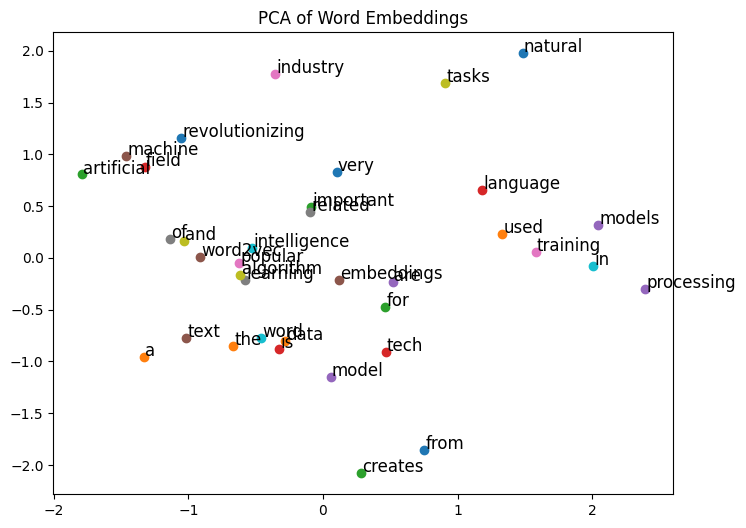

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


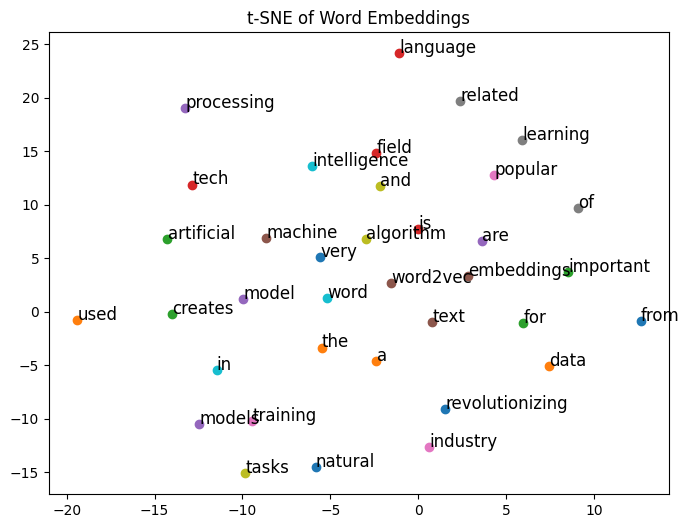

In [ ]:
# Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Step 1: Preparing the Data

corpus = [
    "Machine learning is a field of artificial intelligence",
    "Artificial intelligence and machine learning are very related",
    "Word embeddings are used in natural language processing tasks",
    "The Word2Vec model creates word embeddings from text",
    "Text data is important for training natural language models",
    "Artificial intelligence is revolutionizing the tech industry",
    "Word2Vec is a popular algorithm for learning word embeddings"
]

# Tokenize the sentences
tokenized_corpus = [sentence.lower().split() for sentence in corpus]

# Step 2: Building Vocabulary
vocab = set(word for sentence in tokenized_corpus for word in sentence)
vocab_size = len(vocab)
word_to_index = {word: idx for idx, word in enumerate(vocab)}
index_to_word = {idx: word for word, idx in word_to_index.items()}

# Step 3: Generate Training Data (Skip-gram)

def generate_training_data(tokenized_corpus, window_size=2):
    training_data = []
    for sentence in tokenized_corpus:
        sentence_len = len(sentence)
        for i, word in enumerate(sentence):
            target_word_idx = word_to_index[word]
            context_words = []
            for j in range(i - window_size, i + window_size + 1):
                if j != i and j >= 0 and j < sentence_len:
                    context_word_idx = word_to_index[sentence[j]]
                    context_words.append(context_word_idx)
                    training_data.append((target_word_idx, context_word_idx))
    return np.array(training_data)

training_data = generate_training_data(tokenized_corpus)

# Step 4: Define the Skip-gram Model

class Word2Vec:
    def __init__(self, vocab_size, embedding_dim):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        # Initialize weights
        self.W1 = np.random.uniform(-1, 1, (vocab_size, embedding_dim))
        self.W2 = np.random.uniform(-1, 1, (embedding_dim, vocab_size))

    def softmax(self, x):
        e_x = np.exp(x - np.max(x))
        return e_x / e_x.sum(axis=0)

    def forward(self, one_hot_input):
        h = np.dot(self.W1.T, one_hot_input)  # hidden layer
        u = np.dot(self.W2.T, h)  # output layer
        y_pred = self.softmax(u)
        return y_pred, h

    def backward(self, error, h, one_hot_input, learning_rate):
        dW2 = np.outer(h, error)  # Gradient for W2
        dW1 = np.outer(one_hot_input, np.dot(self.W2, error.T))  # Gradient for W1

        # Update weights
        self.W1 -= learning_rate * dW1
        self.W2 -= learning_rate * dW2

    def train(self, training_data, epochs, learning_rate):
        for epoch in range(epochs):
            loss = 0
            for target_word_idx, context_word_idx in training_data:
                # Generate one-hot vectors
                one_hot_input = np.zeros(self.vocab_size)
                one_hot_input[target_word_idx] = 1
                one_hot_output = np.zeros(self.vocab_size)
                one_hot_output[context_word_idx] = 1

                # Forward pass
                y_pred, h = self.forward(one_hot_input)

                # Compute the loss (cross-entropy)
                loss -= np.log(y_pred[context_word_idx])

                # Compute the error
                error = y_pred - one_hot_output

                # Backpropagation
                self.backward(error, h, one_hot_input, learning_rate)

            if (epoch + 1) % 10 == 0:
                print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss:.4f}')

# Step 5: Train the Model

embedding_dim = 10  # Number of dimensions of the embedding space
word2vec = Word2Vec(vocab_size, embedding_dim)
word2vec.train(training_data, epochs=100, learning_rate=0.01)

# Step 6: Extract Word Embeddings

word_embeddings = word2vec.W1

# Step 7: Visualize the Word Embeddings

def plot_embeddings(embeddings, word_to_index):
    words = list(word_to_index.keys())
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    for i, word in enumerate(words):
        plt.scatter(pca_result[i, 0], pca_result[i, 1])
        plt.text(pca_result[i, 0] + 0.01, pca_result[i, 1] + 0.01, word, fontsize=12)
    plt.title("PCA of Word Embeddings")
    plt.show()

plot_embeddings(word_embeddings, word_to_index)

# Step 8: Visualizing with t-SNE for better clarity

def plot_tsne(embeddings, word_to_index):
    tsne = TSNE(n_components=2, perplexity=15, n_iter=300)
    tsne_result = tsne.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    for i, word in enumerate(word_to_index.keys()):
        plt.scatter(tsne_result[i, 0], tsne_result[i, 1])
        plt.text(tsne_result[i, 0] + 0.01, tsne_result[i, 1] + 0.01, word, fontsize=12)
    plt.title("t-SNE of Word Embeddings")
    plt.show()

plot_tsne(word_embeddings, word_to_index)


In [ ]:
# Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from gensim.models import Word2Vec as GensimWord2Vec

# Corpus
corpus = [
    "Machine learning is a field of artificial intelligence",
    "Artificial intelligence and machine learning are very related",
    "Word embeddings are used in natural language processing tasks",
    "The Word2Vec model creates word embeddings from text",
    "Text data is important for training natural language models",
    "Artificial intelligence is revolutionizing the tech industry",
    "Word2Vec is a popular algorithm for learning word embeddings"
]

# Step 1: Tokenization and Preprocessing
stop_words = set(stopwords.words('english'))
punctuation_table = str.maketrans('', '', string.punctuation)

def preprocess(sentence):
    tokens = word_tokenize(sentence.lower())
    tokens = [word.translate(punctuation_table) for word in tokens]  # remove punctuation
    tokens = [word for word in tokens if word not in stop_words and word.isalpha()]  # remove stopwords
    return tokens

# Preprocessing the corpus
tokenized_corpus = [preprocess(sentence) for sentence in corpus]

# Step 2: Building Vocabulary
vocab = set(word for sentence in tokenized_corpus for word in sentence)
vocab_size = len(vocab)
word_to_index = {word: idx for idx, word in enumerate(vocab)}
index_to_word = {idx: word for word, idx in word_to_index.items()}

# Step 3: Generate Training Data (Skip-gram)
def generate_training_data(tokenized_corpus, window_size=2):
    training_data = []
    for sentence in tokenized_corpus:
        sentence_len = len(sentence)
        for i, word in enumerate(sentence):
            target_word_idx = word_to_index[word]
            for j in range(i - window_size, i + window_size + 1):
                if j != i and j >= 0 and j < sentence_len:
                    context_word_idx = word_to_index[sentence[j]]
                    training_data.append((target_word_idx, context_word_idx))
    return np.array(training_data)

training_data = generate_training_data(tokenized_corpus)

# Step 4: Define the Skip-gram Model
class Word2Vec:
    def __init__(self, vocab_size, embedding_dim):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        # Initialize weights
        self.W1 = np.random.uniform(-1, 1, (vocab_size, embedding_dim))
        self.W2 = np.random.uniform(-1, 1, (embedding_dim, vocab_size))

    def softmax(self, x):
        e_x = np.exp(x - np.max(x))
        return e_x / e_x.sum(axis=0)

    def forward(self, one_hot_input):
        h = np.dot(self.W1.T, one_hot_input)  # hidden layer
        u = np.dot(self.W2.T, h)  # output layer
        y_pred = self.softmax(u)
        return y_pred, h

    def backward(self, error, h, one_hot_input, learning_rate):
        dW2 = np.outer(h, error)  # Gradient for W2
        dW1 = np.outer(one_hot_input, np.dot(self.W2, error.T))  # Gradient for W1

        # Update weights
        self.W1 -= learning_rate * dW1
        self.W2 -= learning_rate * dW2

    def train(self, training_data, epochs, learning_rate):
        for epoch in range(epochs):
            loss = 0
            for target_word_idx, context_word_idx in training_data:
                # Generate one-hot vectors
                one_hot_input = np.zeros(self.vocab_size)
                one_hot_input[target_word_idx] = 1
                one_hot_output = np.zeros(self.vocab_size)
                one_hot_output[context_word_idx] = 1

                # Forward pass
                y_pred, h = self.forward(one_hot_input)

                # Compute the loss (cross-entropy)
                loss -= np.log(y_pred[context_word_idx])

                # Compute the error
                error = y_pred - one_hot_output

                # Backpropagation
                self.backward(error, h, one_hot_input, learning_rate)

            if (epoch + 1) % 10 == 0:
                print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss:.4f}')

# Step 5: Train the Skip-gram Model
embedding_dim = 10  # Number of dimensions of the embedding space
word2vec = Word2Vec(vocab_size, embedding_dim)
word2vec.train(training_data, epochs=100, learning_rate=0.01)

# Step 6: Extract Word Embeddings
word_embeddings = word2vec.W1

# Step 7: Visualize the Word Embeddings using PCA
def plot_embeddings(embeddings, word_to_index):
    words = list(word_to_index.keys())
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    for i, word in enumerate(words):
        plt.scatter(pca_result[i, 0], pca_result[i, 1])
        plt.text(pca_result[i, 0] + 0.01, pca_result[i, 1] + 0.01, word, fontsize=12)
    plt.title("PCA of Word Embeddings")
    plt.show()

plot_embeddings(word_embeddings, word_to_index)

# Step 8: Visualize using t-SNE
def plot_tsne(embeddings, word_to_index):
    tsne = TSNE(n_components=2, perplexity=15, n_iter=300)
    tsne_result = tsne.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    for i, word in enumerate(word_to_index.keys()):
        plt.scatter(tsne_result[i, 0], tsne_result[i, 1])
        plt.text(tsne_result[i, 0] + 0.01, tsne_result[i, 1] + 0.01, word, fontsize=12)
    plt.title("t-SNE of Word Embeddings")
    plt.show()

plot_tsne(word_embeddings, word_to_index)

# Using Gensim's Word2Vec for comparison
gensim_word2vec_model = GensimWord2Vec(sentences=tokenized_corpus, vector_size=100, window=5, min_count=1, workers=4)

# Explore Gensim's trained model
word = "learning"
similar_words = gensim_word2vec_model.wv.most_similar(word)
print(f"Words similar to '{word}':")
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

# Get word vector for 'learning'
word_vector = gensim_word2vec_model.wv['learning']
print("\nVector representation for 'learning':")
print(word_vector)

# Save the Gensim model
gensim_word2vec_model.save("gensim_word2vec_model.model")


LookupError: 
**********************************************************************
  Resource [93mstopwords[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('stopwords')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/stopwords[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************
